# Байесовское сжатие: задача Эфрона–Морриса

**Постановка.** Классический датасет Эфрона–Морриса (1970): 18 бейсболистов, у каждого ровно 45 подач в начале сезона. По ранней доле попаданий $y = r/45$ нужно предсказать истинную результативность игрока $p$ (итог остатка сезона). Наивная оценка (ОМП) $\hat\theta = y$ сильно шумит на 45 наблюдениях.

**Метод.** Бета-биномиальная сопряжённая модель: $\theta \sim \mathrm{Beta}(\alpha, \beta)$, $r \mid \theta \sim \mathrm{Bin}(45, \theta)$. Апостериорное среднее — взвешенная комбинация наивной оценки и априорного среднего, т.е. **сжатие (shrinkage)** индивидуальных оценок к среднему по лиге. Это байесовская интерпретация оценки Джеймса–Стайна.

## Данные

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


In [ ]:
rng = np.random.default_rng(0)
df = pd.read_csv("../data/baseball.csv")
N_AB = 45                      # у всех ровно 45 подач в начале сезона
print("Игроков:", len(df))
df[["name", "r", "y", "p", "n"]].head(6)


Игроков: 18


,name,r,y,p,n
0,Roberto Clemente,18,0.400,0.346,367
1,Frank Robinson,17,0.378,0.298,426
2,Frank Howard,16,0.356,0.276,521
3,Jay Johnstone,15,0.333,0.222,275
4,Ken Berry,14,0.311,0.273,418
5,Jim Spencer,14,0.311,0.270,466


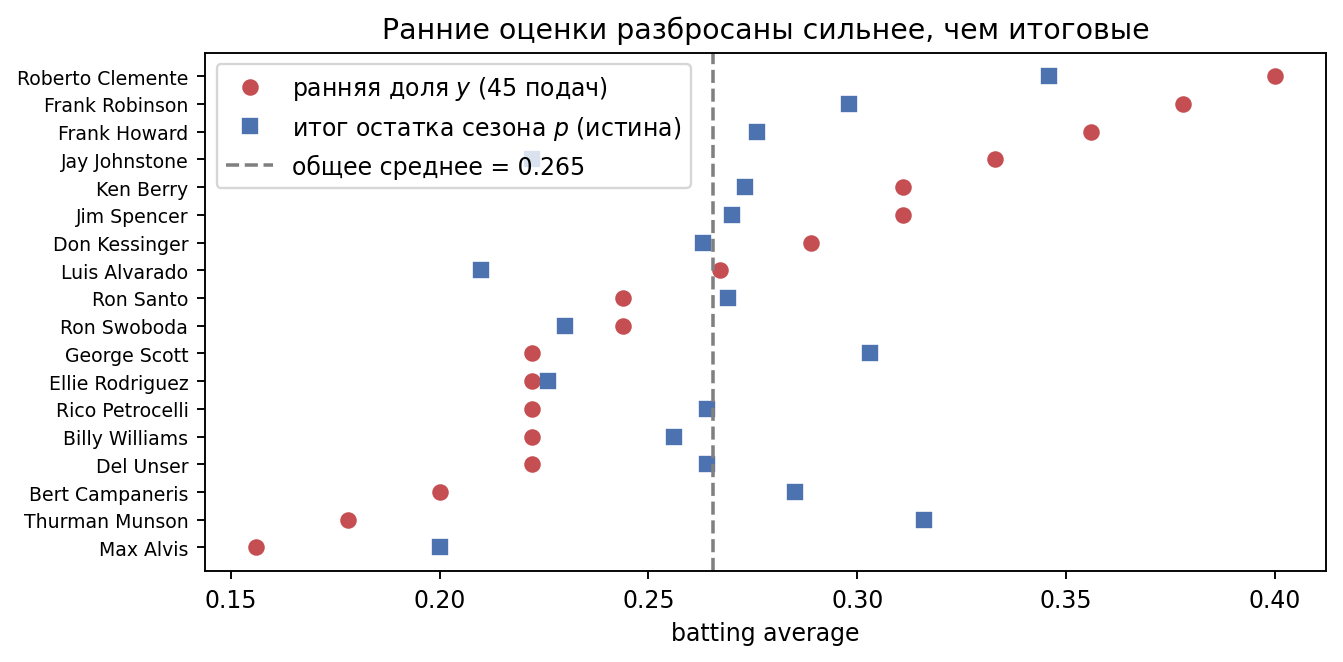

Разброс ранних долей y:  std = 0.070
Разброс итоговых p:      std = 0.038  (заметно меньше!)


In [ ]:
ybar = df.y.mean()

fig, ax = plt.subplots(figsize=(8, 4), dpi=170)

order = df.sort_values("y").index

ax.plot(df.y[order], range(len(df)), "o", color="#C44E52", label="ранняя доля $y$ (45 подач)")
ax.plot(df.p[order], range(len(df)), "s", color="#4C72B0", label="итог остатка сезона $p$ (истина)")
ax.axvline(ybar, color="gray", ls="--", label=f"общее среднее = {ybar:.3f}")
ax.set_yticks(range(len(df))); ax.set_yticklabels(df.name[order], fontsize=8)
ax.set_xlabel("batting average"); ax.legend(); ax.set_title("Ранние оценки разбросаны сильнее, чем итоговые")
plt.tight_layout(); plt.show()
print(f"Разброс ранних долей y:  std = {df.y.std():.3f}")
print(f"Разброс итоговых p:      std = {df.p.std():.3f}  (заметно меньше!)")


Ранние доли $y$ разбросаны заметно сильнее итоговых $p$ — значительная часть разброса ранних оценок — это шум малой выборки, а не различия между игроками. Именно его и должно убрать сжатие.

## Бета-биномиальная модель

Для $\mathrm{Beta}(\alpha,\beta)$-априорного апостериорное среднее равно
$$\mathbb{E}[\theta \mid r] = \frac{\alpha + r}{\alpha + \beta + n} = w\cdot\frac{\alpha}{\alpha+\beta} + (1-w)\cdot\frac{r}{n},\qquad w = \frac{\alpha+\beta}{\alpha+\beta+n},$$
где $w$ — вес априорного знания («$\alpha+\beta$ псевдонаблюдений»).

In [ ]:
# 1.1 Байесовская оценка (апостериорное среднее) для Beta(alpha,beta) prior

def bayes_estimate(r, n, alpha, beta):
    return (alpha + r) / (alpha + beta + n) #E[theta | r] = (alpha+r)/(alpha+beta+n)

def shrinkage_weight(n, alpha, beta):
    return (alpha + beta) / (alpha + beta + n) #w = (alpha+beta)/(alpha+beta+n).

# проверка на Клементе с «плоским» априорным Beta(1,1)

r_clem = int(df.loc[0, "r"])

print(f"Клементе: r={r_clem}/45, ОМП = {r_clem/45:.3f}")
print(f"Байесовская оценка с Beta(1,1): {bayes_estimate(r_clem, 45, 1, 1):.3f}, вес априорного w={shrinkage_weight(45,1,1):.3f}")


Клементе: r=18/45, ОМП = 0.400
Байесовская оценка с Beta(1,1): 0.404, вес априорного w=0.043


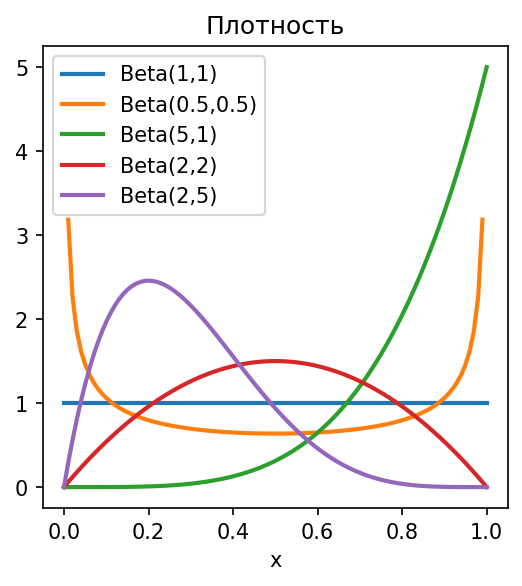

In [ ]:
"""Плотность бета-распределения"""

# Define the parameters for the beta distribution
params = [
    (1, 1),  # alpha = 1, beta = 1
    (0.5, 0.5),  # alpha = 2, beta = 1
    (5, 1),  # alpha = 2, beta = 2
    (2, 2),  # alpha = 2, beta = 2
    (2, 5),  # alpha = 2, beta = 0.5
]

# Create an array of x values
x = np.linspace(0, 1, 100)

# Plot the PDF for each parameter set
plt.figure(figsize=(4, 4), dpi = 150)
for alpha, beta in params:
    plt.plot(x, stats.beta.pdf(x, a = alpha, b = beta), label=f'Beta({alpha},{beta})', linewidth=2)

# Add labels and title
plt.title('Плотность')
plt.xlabel('x')
# plt.ylabel('Density')
plt.legend()
plt.show()


Удобная перепараметризация: априорное задаётся средним $m$ и «силой» $\kappa = \alpha + \beta$ (числом псевдоподач). Возьмём $m$ равным среднему по лиге.

In [ ]:
# 2.1 Перепараметризация (m, kappa) -> (alpha, beta) и байесовская оценка через (m, kappa)

def mk_to_ab(m, kappa):
    alpha = m * kappa
    beta = (1.0 - m) * kappa
    return alpha, beta

# зададим априорное: среднее = общее среднее по лиге, силу kappa подберём

m_prior = df.y.mean()
KAPPA = 90.0                     # «90 псевдоподач» — мы вернёмся к выбору kappa в Части 3

alpha0, beta0 = mk_to_ab(m_prior, KAPPA)
print(f"Априорное: m={m_prior:.3f}, kappa={KAPPA}  ->  Beta(alpha={alpha0:.2f}, beta={beta0:.2f})")

# применим ко всем игрокам
df["bayes"] = bayes_estimate(df.r.values, N_AB, alpha0, beta0)
print(df[["name","y","bayes","p"]].head(6).to_string(index=False))


Априорное: m=0.265, kappa=90.0  ->  Beta(alpha=23.88, beta=66.11)
            name     y    bayes     p
Roberto Clemente 0.400 0.310259 0.346
  Frank Robinson 0.378 0.302852 0.298
    Frank Howard 0.356 0.295444 0.276
   Jay Johnstone 0.333 0.288037 0.222
       Ken Berry 0.311 0.280630 0.273
     Jim Spencer 0.311 0.280630 0.270


## Качество прогноза: наивная оценка vs байесовская

In [ ]:
# 2.2 Сравнение качества прогноза: SSE наивной vs байесовской оценки

y = df.y.values; p = df.p.values; bayes = df.bayes.values

sse_naive = np.sum((y - p) ** 2)
sse_bayes = np.sum((bayes - p) ** 2)

print(f"sse наивной оценки равно {sse_naive:.5f}")
print(f"sse байесовской оценки равно {sse_bayes:.5f}")
print(f"Отношение sse_naive/sse_bayes равно {sse_naive / sse_bayes:.2f}")


sse наивной оценки равно 0.07537
sse байесовской оценки равно 0.02296
Отношение sse_naive/sse_bayes равно 3.28


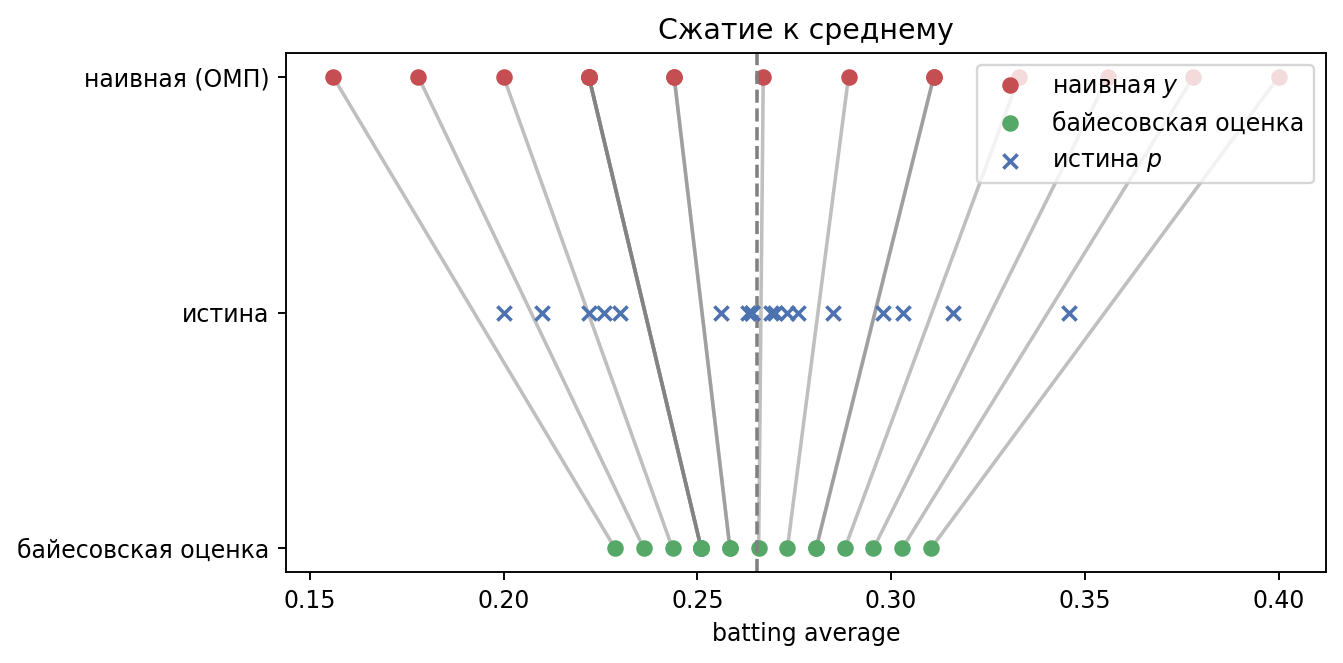

In [ ]:
#Картинка сжатия:

fig, ax = plt.subplots(figsize=(8, 4), dpi=170)

for i in range(len(df)):
    ax.plot([df.y[i], df.bayes[i]], [1, 0], "-", color="gray", alpha=0.5)

ax.plot(df.y, [1]*len(df), "o", color="#C44E52", label="наивная $y$")
ax.plot(df.bayes, [0]*len(df), "o", color="#55A868", label="байесовская оценка")
ax.axvline(df.y.mean(), color="gray", ls="--")
ax.scatter(df.p, [0.5]*len(df), marker="x", color="#4C72B0", label="истина $p$", zorder=3)
ax.set_yticks([0,0.5,1]); ax.set_yticklabels(["байесовская оценка","истина","наивная (ОМП)"])
ax.set_xlabel("batting average"); ax.legend(loc="upper right"); ax.set_title("Сжатие к среднему")
plt.tight_layout(); plt.show()


Сжатие к среднему по лиге снижает суммарную квадратичную ошибку прогноза в несколько раз — тот самый парадоксальный результат Эфрона–Морриса: смещённая оценка бьёт несмещённую ОМП по суммарному риску.

## Выбор силы априорного: SSE как функция $\kappa$

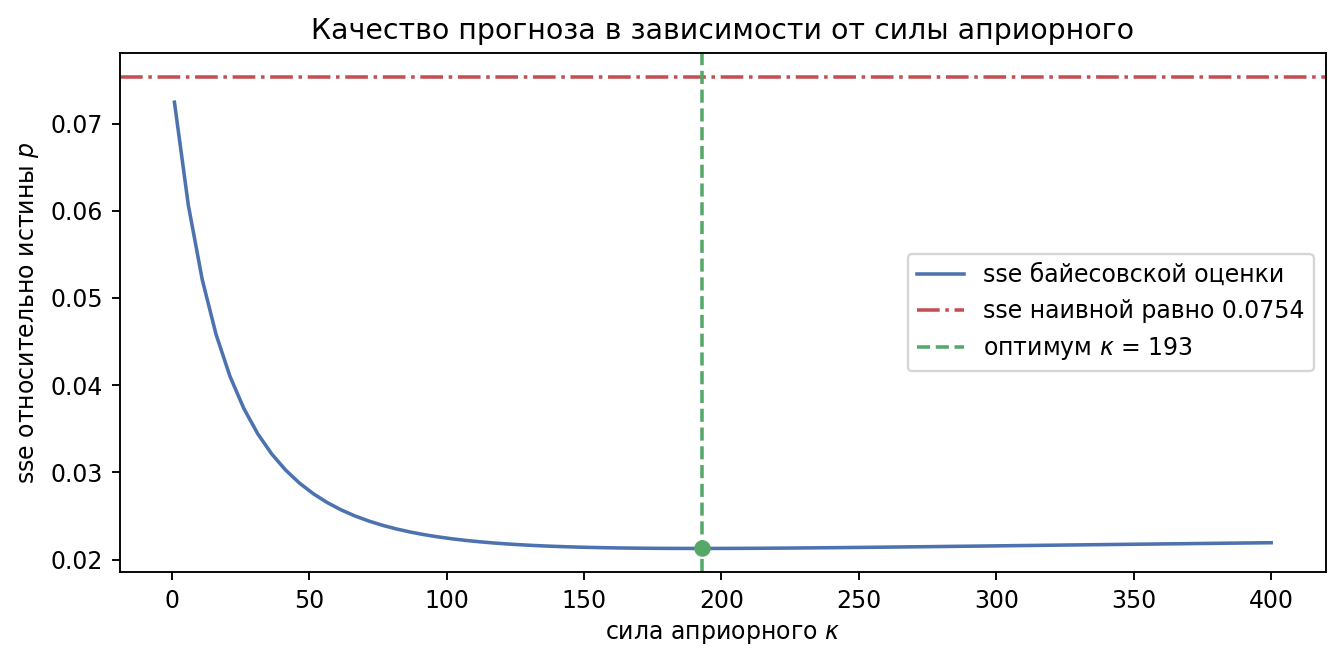

Оптимальное k = 192.9
Минимальная sse = 0.02127
sse наивной оценки = 0.07537
Выигрыш в 3.54 раз


In [ ]:
# 3.1 Качество прогноза (SSE) как функция силы априорного kappa

kappas = np.linspace(1, 400, 80)
m_prior = df.y.mean()

p = df.p.values
r_all = df.r.values
sse_naive = np.sum((df.y.values - p) ** 2)   #горизонтальная линия это наивная оценка

sse_list = []
for kappa in kappas:
    alpha, beta = mk_to_ab(m_prior, kappa)
    est = bayes_estimate(r_all, N_AB, alpha, beta)
    sse_list.append(np.sum((est - p) ** 2))
sse_list = np.array(sse_list)

kappa_best = kappas[np.argmin(sse_list)]
sse_best = sse_list.min()

fig, ax = plt.subplots(figsize=(8, 4), dpi=170)
ax.plot(kappas, sse_list, "-", color="#4C72B0", label="sse байесовской оценки")
ax.axhline(sse_naive, color="#C44E52", ls="dashdot", label=f"sse наивной равно {sse_naive:.4f}")
ax.axvline(kappa_best, color="#55A868", ls="dashed", label=f"оптимум $\\kappa$ = {kappa_best:.0f}")
ax.plot(kappa_best, sse_best, "o", color="#55A868")
ax.set_xlabel(r"сила априорного $\kappa$")
ax.set_ylabel("sse относительно истины $p$")
ax.set_title("Качество прогноза в зависимости от силы априорного")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальное k = {kappa_best:.1f}")
print(f"Минимальная sse = {sse_best:.5f}")
print(f"sse наивной оценки = {sse_naive:.5f}")
print(f"Выигрыш в {sse_naive / sse_best:.2f} раз")


## Поведение при росте выборки: байесовская оценка стремится к ОМП

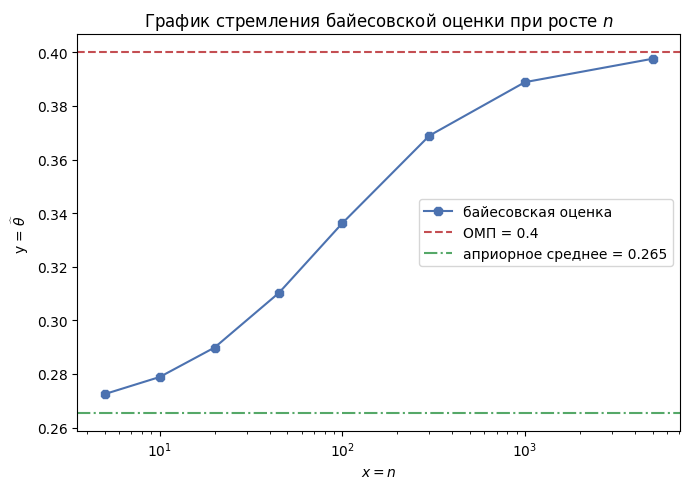

Для n  =    5 байесовская оценка равна 0.2725
Для n  =   10 байесовская оценка равна 0.2788
Для n  =   20 байесовская оценка равна 0.2899
Для n  =   45 байесовская оценка равна 0.3103
Для n  =  100 байесовская оценка равна 0.3362
Для n  =  300 байесовская оценка равна 0.3689
Для n  = 1000 байесовская оценка равна 0.3889
Для n  = 5000 байесовская оценка равна 0.3976


In [ ]:
# 3.3 Байесовская оценка -> ОМП при росте n (доля попаданий фиксирована = 0.4)

ns = np.array([5, 10, 20, 45, 100, 300, 1000, 5000])
true_rate = 0.40
alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

estimates = []
for n in ns:
    r = round(true_rate * n)
    estimates.append(bayes_estimate(r, n, alpha0, beta0))
estimates = np.array(estimates)

prior_mean = alpha0/(alpha0 + beta0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ns, estimates, "8-", color="#4C72B0", label="байесовская оценка")
ax.axhline(true_rate, color="#C44E52", ls="--", label=f"ОМП = {true_rate}")
ax.axhline(prior_mean, color="#55A868", ls="dashdot", label=f"априорное среднее = {prior_mean:.3f}")
ax.set_xscale("log")
ax.set_xlabel("$x = n$")
ax.set_ylabel(r"y = $\widehat\theta$")
ax.set_title(r"График стремления байесовской оценки при росте $n$")
ax.legend()
plt.tight_layout()
plt.show()

for n, e in zip(ns, estimates):
    print(f"Для n  ={n:5d} байесовская оценка равна {e:.4f}")


## Credible-интервалы из апостериорного распределения

In [ ]:
# 4.1 Равнохвостый 95% credible-интервал из апостериорного Beta

def credible_interval(r, n, alpha, beta, gamma=0.05):
    a_post = alpha + r
    b_post = beta + n - r
    L = stats.beta.ppf(gamma / 2, a_post, b_post)
    U = stats.beta.ppf(1 - gamma / 2, a_post, b_post)
    return L, U

# для каждого игрока: точечная байесовская оценка + 95% credible-интервал

alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

for i in [0, 16, 17]:                  # Клементе, Мансон, Макс Алвис
    L, U = credible_interval(df.r[i], N_AB, alpha0, beta0)
    print(f"{df.name[i]:18s} байесовская оценка={df.bayes[i]:.3f}, 95% CI=[{L:.3f}, {U:.3f}], истина p={df.p[i]:.3f}")


Roberto Clemente   байесовская оценка=0.310, 95% CI=[0.235, 0.391], истина p=0.346
Thurman Munson     байесовская оценка=0.236, 95% CI=[0.169, 0.311], истина p=0.316
Max Alvis          байесовская оценка=0.229, 95% CI=[0.162, 0.303], истина p=0.200


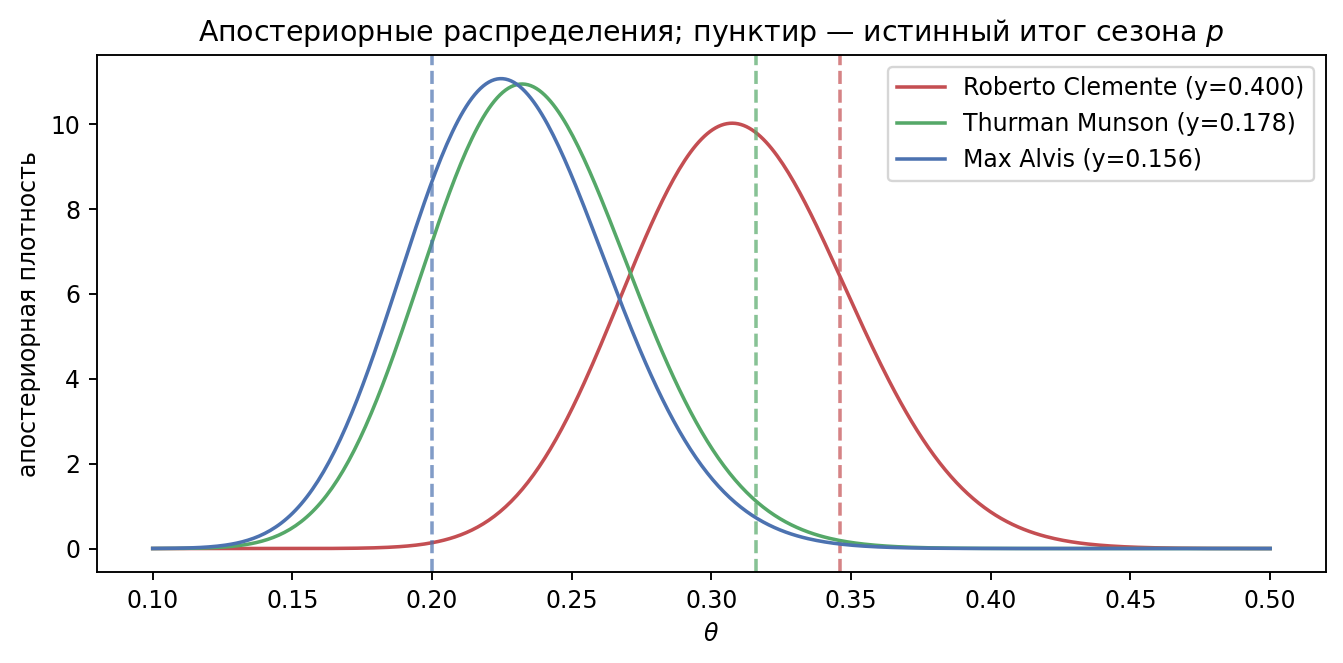

In [ ]:
# Картинка: апостериорные плотности и credible-интервалы для трёх игроков

alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

grid = np.linspace(0.1, 0.5, 400)

plt.figure(figsize=(8,4), dpi=170)

for i, col in zip([0, 16, 17], ["#C44E52", "#55A868", "#4C72B0"]):
    post = stats.beta.pdf(grid, alpha0 + df.r[i], beta0 + N_AB - df.r[i])
    plt.plot(grid, post, color=col, label=f"{df.name[i]} (y={df.y[i]:.3f})")
    plt.axvline(df.p[i], color=col, ls="--", alpha=0.7)
plt.xlabel(r"$\theta$"); plt.ylabel("апостериорная плотность")
plt.title("Апостериорные распределения; пунктир — истинный итог сезона $p$")
plt.legend(); plt.tight_layout(); plt.show()


## Функция потерь: апостериорное среднее vs медиана

In [ ]:
# 5.1 Сравнение байес-оценок при квадратичных  и абсолютных потерях
alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

def bayes_median(r, n, alpha, beta):
    return stats.beta.median(alpha + r, beta + n - r)

for i in [0, 16]:

    mean_est = bayes_estimate(df.r[i], N_AB, alpha0, beta0)
    med_est  = bayes_median(df.r[i], N_AB, alpha0, beta0)
    print(f"{df.name[i]:18s} среднее={mean_est:.4f}, медиана={med_est:.4f}, разница={abs(mean_est-med_est):.4f}")


Roberto Clemente   среднее=0.3103, медиана=0.3093, разница=0.0009
Thurman Munson     среднее=0.2362, медиана=0.2349, разница=0.0013


## Выводы

- На малых выборках сжатие индивидуальных оценок к общему среднему кратно снижает суммарную ошибку прогноза (SSE) по сравнению с наивной ОМП.
- Сила априорного $\kappa$ — гиперпараметр смещения/дисперсии: слишком слабое априорное не убирает шум, слишком сильное затирает реальные различия между игроками.
- С ростом $n$ вес априорного $w \to 0$ и байесовская оценка сходится к ОМП.
- Та же механика лежит в основе сглаживания CTR новых объявлений, рейтингов товаров с малым числом отзывов и mean-target encoding в ML.